In [2]:
# verifikasi lingkungan kerja

import sys, platform, multiprocessing

print("Python version:", sys.version.split()[0])
print("OS:", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

print("Python version:", sys.version.split()[0])
print("OS:", platform.platform())

Python version: 3.13.15
OS: Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
Python version: 3.13.15
OS: Linux-6.6.122+-x86_64-with-glibc2.39


Melakukan pengecekan dan verifikasi lingkungan kerja yaitu dengan melakukan pemeriksaan pada spesifikasi mesinnya, menggunakan modul/library bawaan python, dan cek apakah pustaka tersebut sudah terpasang atau belum.

---



In [3]:
!free -h
!df -h /content
!java -version

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.4Gi       8.4Gi       2.1Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.032s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.032s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


Melakukan cek dan pemeriksaan untuk kapasitas dan sisa ram, disk runtime, dan ketersediaan java.

In [4]:
# menghubungkan google drive & menyiapkan struktur folder

from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"

os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png']


Melakukan connect google collab ke google drive dengan memunculkan dialog izin untuk menautkan google drive ke collab, dan membuat direktori pada google drive tersebut, pada path tertentu.

In [5]:
# menyiapkan alat ukur waktu & memori

import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
  return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
  """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
  m0, t0 = rss_mb(), time.perf_counter()
  hasil = fungsi()
  detik = time.perf_counter() - t0
  delta = rss_mb() - m0
  catatan.append({"langkah": label, "detik": round(detik, 2),
                  "delta_rss_mb": round(delta,1)})
  print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
  return hasil

Kode digunakan untuk menyiapkan pengukuran waktu eksekusi dan penggunaan memori pada setiap proses. Fungsi ukur() menjalankan suatu fungsi sekaligus mencatat durasi proses dan perubahan penggunaan memori.

In [6]:
# mengunduh dataset dan inspeksi awal

import urllib.request

URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
"yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
  ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset] 0.33 s | RSS +1.9 MB
Ukuran file: 45.5 MB


Kode digunakan untuk mengunduh dataset Yellow Taxi Trip Data bulan Januari 2023 dalam format Parquet. Setelah proses pengunduhan, ukuran file diperiksa untuk mengetahui besarnya dataset yang digunakan.

In [7]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


Kode digunakan untuk melakukan inspeksi metadata pada dataset Parquet tanpa memuat seluruh data ke memori. Informasi yang diperoleh meliputi jumlah baris, jumlah kolom, jumlah row group, dan nama kolom dalam dataset.

In [8]:
# memuat data dan mengukur biaya memorinya

import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet (PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024 ** 2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet (PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024 ** 2, 1), "MB")
df.head()

[baca semua kolom] 2.00 s | RSS +495.5 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 1.57 s | RSS +211.0 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


Kode digunakan untuk membandingkan penggunaan waktu dan memori saat membaca seluruh kolom dengan saat hanya membaca kolom yang diperlukan. Setelah itu, dataset dengan kolom terpilih dimuat ke dalam df untuk digunakan pada proses pengolahan berikutnya.

In [9]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


Kode digunakan untuk memeriksa struktur dataset dan penggunaan memori pada setiap kolom. Informasi tersebut membantu mengidentifikasi ukuran memori yang digunakan oleh data sebelum dilakukan pengolahan lebih lanjut.

In [10]:
sebelum = df.memory_usage(deep=True).sum() / 1024 ** 2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
  df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024 ** 2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


Kode digunakan untuk mengoptimalkan penggunaan memori dengan menyesuaikan tipe data pada beberapa kolom, seperti mengubah tipe numerik ke ukuran yang lebih kecil dan payment_type menjadi category. Penggunaan memori sebelum dan sesudah optimasi kemudian dibandingkan untuk mengetahui penghematan yang diperoleh.

In [11]:
# pemeriksaan kualitas data dan pembersihan (veracity)

df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0" : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0" : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit" : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0" : (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
  print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


Kode digunakan untuk memeriksa kualitas data dengan menghitung durasi perjalanan, nilai statistik dasar, dan jumlah data kosong pada setiap kolom. Beberapa kondisi anomali, seperti jarak atau durasi yang tidak valid serta nilai total_amount yang tidak positif, juga dihitung untuk mengetahui tingkat ketidaksesuaian data.

In [12]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris (dibuang 79,855)


Kode digunakan untuk menyaring data berdasarkan kriteria kelayakan yang telah ditentukan, yaitu jarak, durasi perjalanan, dan total_amount. Data yang memenuhi seluruh kriteria disimpan dalam dataframe bersih untuk digunakan pada tahap analisis berikutnya.

In [13]:
# memproses file lebih besar dari memori dengan chunking

CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur ("tulis CSV", lambda: bersih.to_csv (CSV, index=False))
print("Parquet:", round (os.path.getsize (PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize (CSV) / 1024**2, 1), "MB")

def agregasi_bertahap (path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk ["total_amount"].sum()
        for jam, sub in chunk.groupby (chunk ["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub ["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap (CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 42.31 s | RSS +5.3 MB
Parquet: 45.5 MB
CSV    : 226.2 MB
[agregasi chunking] 5.54 s | RSS +20.1 MB
2,986,911 baris | rata-rata total_amount = 27.33


Kode digunakan untuk menerapkan teknik chunking dalam membaca dan mengolah data secara bertahap sehingga tidak seluruh data dimuat ke memori sekaligus. Proses agregasi dilakukan berdasarkan jumlah baris, total total_amount, dan distribusi data berdasarkan jam pengambilan.

In [14]:
# pendekatan terdistribusi : pyspark local mode!

!pip install -q pyspark==3.5.1
!java -version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 14.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[0.026s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.026s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


Kode digunakan untuk menyiapkan lingkungan pemrosesan terdistribusi menggunakan PySpark dalam local mode. Instalasi PySpark dilakukan terlebih dahulu, kemudian versi Java diperiksa sebagai salah satu kebutuhan untuk menjalankan Spark.

In [15]:
from pyspark.sql import SparkSession, functions as F
spark = (
    SparkSession.builder
    .appName("BD-P01")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel ("WARN")
print("Spark:", spark.version)

sdf = spark.read.parquet (PATH)
sdf.printSchema()
print("Jumlah baris:", ukur ("spark count", lambda: sdf.count()))

sdf_bersih = (
    sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60
    )
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col ("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0)
)

hasil_spark = (
    sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam")
)

ukur ("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

Spark: 3.5.1
root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 4.10 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|ra

Kode digunakan untuk menjalankan pengolahan dataset menggunakan PySpark dalam mode lokal, mulai dari pembacaan data hingga penyaringan berdasarkan kriteria kelayakan. Data yang telah dibersihkan kemudian dikelompokkan berdasarkan jam pengambilan untuk menghitung jumlah perjalanan, rata-rata jarak, dan rata-rata tarif.

In [16]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
SELECT payment_type,
       COUNT(*) AS jumlah,
       ROUND (AVG (total_amount), 2) AS rata_tarif,
       ROUND (AVG(tip_amount), 2) AS rata_tip
FROM trips
GROUP BY payment_type
ORDER BY jumlah DESC
""").show()

hasil_spark.explain() #rencana eksekusi perhatikan Exchange / HashAggregate
spark.stop() #bebaskan sumber daya sebelum lanjut

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#84 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#84 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=206]
      +- HashAggregate(keys=[jam#84], functions=[count(1), avg(trip_distance#4), avg(total_amount#16)])
         +- Exchange hashpartitioning(jam#84, 8), ENSURE_REQUIREMENTS, [plan_id=203]
            +- HashAggregate(keys=[jam#84], functions=[partial_count(1), partial_avg(trip_distance#4), partial_avg(total_amount#16)])
               +- Project [trip_distance#4, total_amount#16, hour(tpep_pickup_datetime#1, Some(

In [17]:
# agregasi akhir dengan pandas & penyimpanan artefak

bersih ["jam"] = bersih ["tpep_pickup_datetime"].dt.hour
agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round (2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet (f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame (catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


Kode digunakan untuk melakukan agregasi akhir menggunakan Pandas berdasarkan jam pengambilan perjalanan. Hasil agregasi disimpan dalam format CSV dan Parquet, sedangkan catatan pengukuran kinerja disimpan sebagai file CSV untuk digunakan dalam analisis.

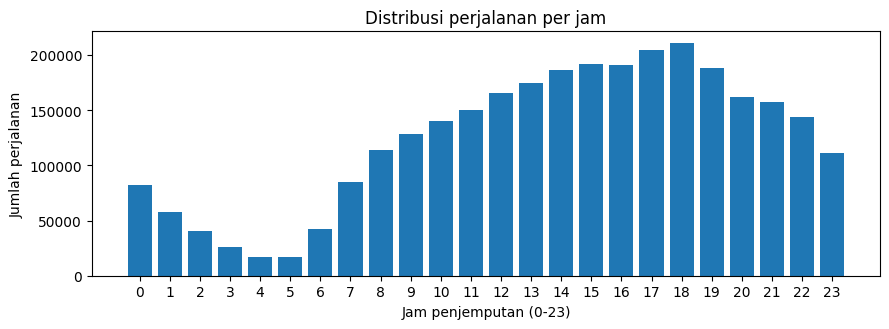

In [18]:
# visualisasi hasil

import matplotlib.pyplot as plt
fig, ax = plt.subplots (figsize=(9, 3.4))
ax.bar (agregasi ["jam"], agregasi ["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks (range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

Kode digunakan untuk memvisualisasikan distribusi jumlah perjalanan berdasarkan jam penjemputan dalam bentuk diagram batang. Grafik kemudian disimpan sebagai file gambar untuk digunakan sebagai artefak hasil analisis.

In [19]:
#analisis

import pandas as pd
kinerja = pd.DataFrame(catatan)
kinerja

,langkah,detik,delta_rss_mb
0,unduh dataset,0.33,1.9
1,baca semua kolom,2.00,495.5
2,baca kolom terpilih,1.57,211.0
3,tulis CSV,42.31,5.3
4,agregasi chunking,5.54,20.1
5,spark count,4.10,0.0
6,spark agregasi,6.44,0.0


,akhir_pekan,jam,jumlah,rata_durasi,rata_tarif_per_menit
0,False,0,35351,14.10,2.57
1,False,1,17516,13.04,2.66
2,False,2,9452,12.23,2.63
3,False,3,6238,12.87,2.72
4,False,4,6192,14.79,2.81
5,False,5,12462,14.63,2.82
6,False,6,35728,14.57,2.33
7,False,7,74157,14.66,2.07
8,False,8,98431,14.82,1.90
9,False,9,103263,15.03,1.90


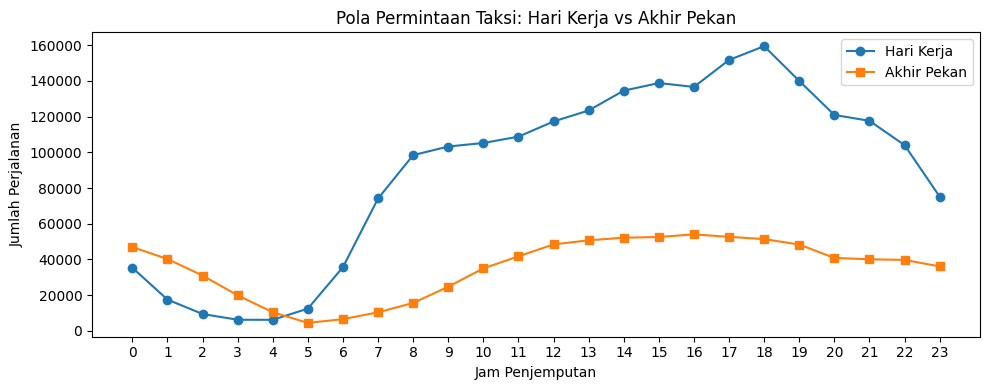

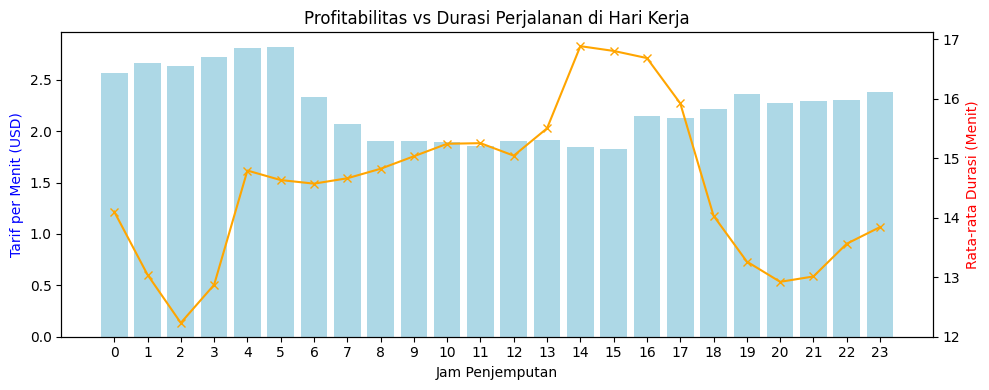

In [20]:
import matplotlib.pyplot as plt

# 1. Menambahkan kolom hari dan metrik profitabilitas sesuai modul
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

# 2. Agregasi data (tabel ringkasan)
ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index() # Di-reset index agar mudah di-plot
)
display(ringkas.head(12)) # Menampilkan tabel

# Memisahkan data hari kerja dan akhir pekan untuk plotting
hari_kerja = ringkas[ringkas['akhir_pekan'] == False]
akhir_pekan = ringkas[ringkas['akhir_pekan'] == True]

# GRAFIK 1: Menjawab pola jam permintaan & beda hari kerja vs akhir pekan
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hari_kerja['jam'], hari_kerja['jumlah'], label='Hari Kerja', marker='o')
ax.plot(akhir_pekan['jam'], akhir_pekan['jumlah'], label='Akhir Pekan', marker='s')
ax.set_title("Pola Permintaan Taksi: Hari Kerja vs Akhir Pekan")
ax.set_xlabel("Jam Penjemputan")
ax.set_ylabel("Jumlah Perjalanan")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

# GRAFIK 2: Menjawab profitabilitas vs durasi rute (Fokus Hari Kerja)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx() # Menggabungkan dua sumbu Y
ax1.bar(hari_kerja['jam'], hari_kerja['rata_tarif_per_menit'], color='lightblue', label='Tarif/Menit')
ax2.plot(hari_kerja['jam'], hari_kerja['rata_durasi'], color='orange', marker='x', label='Durasi')
ax1.set_xlabel("Jam Penjemputan")
ax1.set_ylabel("Tarif per Menit (USD)", color='blue')
ax2.set_ylabel("Rata-rata Durasi (Menit)", color='red')
plt.title("Profitabilitas vs Durasi Perjalanan di Hari Kerja")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [21]:
# Menampilkan 5 baris dengan trip_distance terbesar
top_5_jarak = bersih.nlargest(5, 'trip_distance')
display(top_5_jarak[['trip_distance', 'durasi_menit', 'total_amount']])

,trip_distance,durasi_menit,total_amount
1748933,96.70,136.416667,440.750000
526988,93.05,96.333333,564.049988
2402193,92.60,143.083333,312.799988
2902389,92.00,148.500000,368.149994
927215,90.63,114.050000,272.299988


In [22]:
print("=== Chunksize 100.000 ===")
_, _, _ = ukur("chunking 100k", lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000))

print("\n=== Chunksize 1.000.000 ===")
_, _, _ = ukur("chunking 1M", lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000))

=== Chunksize 100.000 ===
[chunking 100k] 4.91 s | RSS +57.4 MB

=== Chunksize 1.000.000 ===
[chunking 1M] 6.21 s | RSS +82.4 MB


In [23]:
import numpy as np

# Menghitung persentase tip, jika fare_amount 0, hasilnya 0
bersih["persen_tip"] = np.where(bersih["fare_amount"] > 0,
                                (bersih["tip_amount"] / bersih["fare_amount"]) * 100,
                                0.0)

# Menghitung rata-rata persen tip per payment_type
rata_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2)
display(rata_tip)

/tmp/ipykernel_2521/1195851826.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_tip = bersih.groupby("payment_type")["persen_tip"].mean().round(2)


,persen_tip
payment_type,
0,20.23
1,25.91
2,0.00
3,0.02
4,0.15


In [24]:
# Mengukur waktu tulis
ukur("tulis snappy", lambda: bersih.to_parquet(f"{DIR_SIMPAN}/bersih_snappy.parquet", index=False, compression="snappy"))
ukur("tulis gzip", lambda: bersih.to_parquet(f"{DIR_SIMPAN}/bersih_gzip.parquet", index=False, compression="gzip"))

# Membandingkan ukuran file
print("Ukuran file Snappy:", round(os.path.getsize(f"{DIR_SIMPAN}/bersih_snappy.parquet") / 1024**2, 1), "MB")
print("Ukuran file Gzip  :", round(os.path.getsize(f"{DIR_SIMPAN}/bersih_gzip.parquet") / 1024**2, 1), "MB")

[tulis snappy] 4.29 s | RSS +43.2 MB
[tulis gzip] 45.39 s | RSS -10.5 MB
Ukuran file Snappy: 63.3 MB
Ukuran file Gzip  : 51.0 MB


In [27]:
from pyspark.sql import SparkSession

# 1. Menghidupkan kembali sesi Spark
spark = SparkSession.builder.appName("Latihan5").master("local[*]").getOrCreate()

# 2. Mengubah pandas DataFrame 'bersih' menjadi Spark DataFrame & membuat tabel virtual
sdf_latihan = spark.createDataFrame(bersih)
sdf_latihan.createOrReplaceTempView("trips_bersih")

# 3. Menulis ulang agregasi memakai Spark SQL (mirip dengan J-9)
spark_agg = spark.sql("""
    SELECT HOUR(tpep_pickup_datetime) AS jam,
           COUNT(*) AS jumlah_perjalanan,
           ROUND(AVG(trip_distance), 2) AS rata_jarak,
           ROUND(AVG(durasi_menit), 2) AS rata_durasi,
           ROUND(AVG(total_amount), 2) AS rata_tarif
    FROM trips_bersih
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY jam
""").toPandas() # Dikonversi kembali ke pandas agar mudah dibandingkan

# 4. Membuktikan konsistensi hasil dengan membandingkan kolom 'jumlah_perjalanan'
selisih_maks = (spark_agg["jumlah_perjalanan"] - agregasi["jumlah_perjalanan"]).abs().max()
print(f"Selisih maksimum kolom jumlah_perjalanan: {selisih_maks}")

# Tutup kembali sesinya
spark.stop()

Selisih maksimum kolom jumlah_perjalanan: 0
